In [2]:
import pandas as pd, numpy as np
df=pd.read_csv('./data/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
# Structural overview
print(f"Shape: {df.shape}")

Shape: (891, 12)


In [6]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [9]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [11]:
print(df.tail(5))

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [14]:
print(df.sample(5, random_state=0))

     PassengerId  Survived  Pclass  \
495          496         0       3   
648          649         0       3   
278          279         0       3   
31            32         1       1   
255          256         1       3   

                                               Name     Sex   Age  SibSp  \
495                           Yousseff, Mr. Gerious    male   NaN      0   
648                              Willey, Mr. Edward    male   NaN      0   
278                              Rice, Master. Eric    male   7.0      4   
31   Spencer, Mrs. William Augustus (Marie Eugenie)  female   NaN      1   
255         Touma, Mrs. Darwis (Hanne Youssef Razi)  female  29.0      0   

     Parch         Ticket      Fare Cabin Embarked  
495      0           2627   14.4583   NaN        C  
648      0  S.O./P.P. 751    7.5500   NaN        S  
278      1         382652   29.1250   NaN        Q  
31       0       PC 17569  146.5208   B78        C  
255      2           2650   15.2458   NaN        

In [18]:
missing=df.isnull().sum()
missing  

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [21]:
missing_pct=100*missing/len(df)
missing_pct

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [24]:
 missing_report=pd.DataFrame({
     'missing_report':missing,
     'missing_pct':missing_pct.round(2)
 }).sort_values('missing_pct', ascending=False)

 missing_report

,missing_report,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [28]:
cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique | top: {df[col].value_counts().index[0]}')

Name: 891 unique | top: Braund, Mr. Owen Harris
Sex: 2 unique | top: male
Ticket: 681 unique | top: 347082
Cabin: 147 unique | top: G6
Embarked: 3 unique | top: S


C:\Users\THE EYE INFORMATIQUE\AppData\Local\Temp\ipykernel_23372\706839807.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include='object').columns


## Phase 1: Data Audit & Initial Inspection

he Goal: Load the data and check for "Silent Killers" (missing values, wrong data types).

In [31]:
import pandas as pd

# Load the data
df = pd.read_csv('House_Price_Prediction_Dataset.csv')

# Inspection
print(df.info())
# print(df.describe())
# print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB
None


## The "Why":
    
info(): Checks if "Price" is an integer or an object. If it's an object, the model can't do math on it.

isnull(): If we have missing values, the model will crash during training.

Dry Run Example:
Input Row 1: 1, 1360, 5, 4, 3, 1970, Downtown, Excellent, No, 149919
Logic Check: Is 1360 (Area) a number? Yes. Is "Excellent" text? Yes.
Result: The audit confirms we have 1,000+ rows and no missing values. We are ready to proceed.

## Phase 2: Deep EDA (The Discovery)

The Goal: Find out which features actually "push" the price up or down.

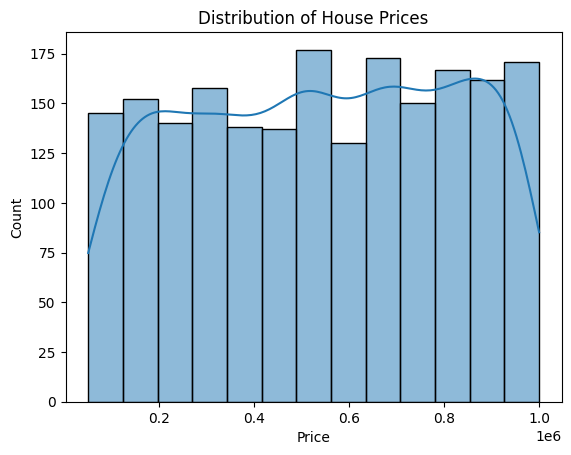

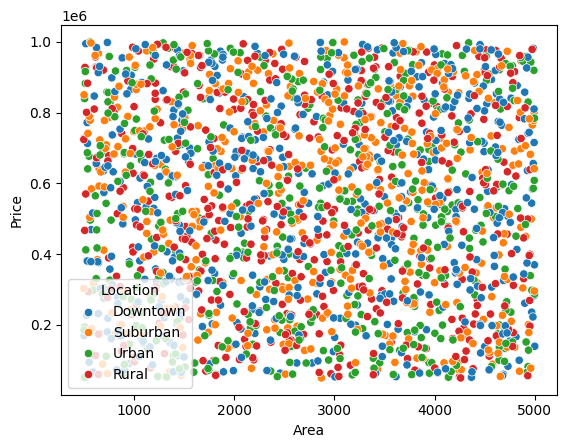

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize the price distribution
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

# 2. Correlation between Area and Price
sns.scatterplot(data=df, x='Area', y='Price', hue='Location')
plt.show()

## The "Why":

Histogram: We check for Skewness. If most houses are 100k but one is $10M, the model will get "confused."

Scatter Plot: This shows if the relationship is a straight line. If Area goes up, does Price always go up?

Dry Run Example:

Data Comparison:

Row 2: 4272 sqft, Downtown, Excellent 

 $424,998
 
Row 6: 3944 sqft, Urban, Poor 

 $93,262
 
Discovery: Even though Row 6 is large, its "Poor" condition and "Urban" location crashed the price. This tells us Condition is a more powerful predictor than Area alone.



## hase 3: Feature Engineering (The Transformation)

The Goal: Convert text (Downtown, Excellent) into numbers that math can understand.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df.drop('Price', axis=1) # Features
y = df['Price']              # Target

# Split data: 80% for learning, 20% for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

      Area  Bedrooms  Bathrooms  Floors  YearBuilt  Condition  Garage  \
968   4483         4          4       3       1933          3       0   
240   1062         3          3       1       1970          2       0   
819   1422         3          4       1       1993          2       1   
692   2658         2          3       1       1972          0       1   
420   3286         2          4       1       1981          3       1   
...    ...       ...        ...     ...        ...        ...     ...   
1130  3483         5          3       3       1931          2       1   
1294  1747         3          3       2       1941          1       1   
860   1484         2          3       3       1973          2       0   
1459  3456         5          4       1       1955          2       1   
1126  1682         2          1       3       2006          2       0   

      Loc_Downtown  Loc_Rural  Loc_Suburban  Loc_Urban  
968          False      False         False       True  
240      

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

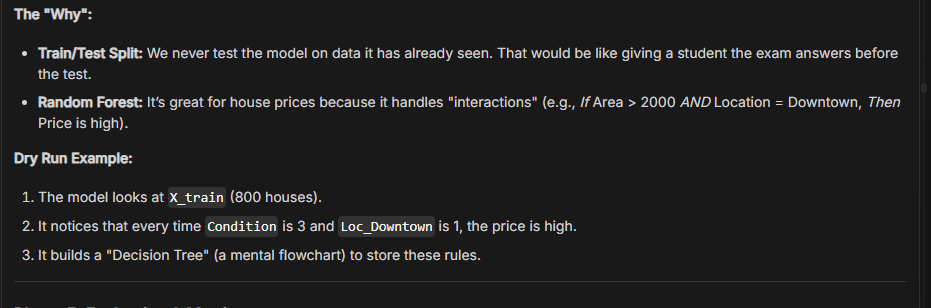

## Step 1: Preprocessing (The Fix for 'Urban')
Before you run model.fit(), you must transform the categorical columns.

In [42]:
# 1. Handle the 'Garage' column (Binary: 0 or 1)
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

# 2. Handle the 'Condition' column (Ordinal: logic order)
# We give them a scale of 0 to 3
cond_map = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
df['Condition'] = df['Condition'].map(cond_map)

# 3. Handle the 'Location' column (One-Hot Encoding)
# This turns 'Location' into three columns: Loc_Urban, Loc_Rural, Loc_Downtown
# containing only 1s and 0s.
df = pd.get_dummies(df, columns=['Location'], prefix='Loc')

# 4. Drop the ID column (It's just a label, not a predictor)
df = df.drop('Id', axis=1)

print(df.head()) # Look at the data now - it should be all numbers!

   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Condition  Garage   Price  \
0  1360         5          4       3       1970          3       0  149919   
1  4272         5          4       3       1958          3       0  424998   
2  3592         2          2       3       1938          2       0  266746   
3   966         4          2       2       1902          1       1  244020   
4  4926         1          4       2       1975          1       1  636056   

   Loc_Downtown  Loc_Rural  Loc_Suburban  Loc_Urban  
0          True      False         False      False  
1          True      False         False      False  
2          True      False         False      False  
3         False      False          True      False  
4          True      False         False      False  


## Phase 5: Evaluation & Metrics

The Goal: Check how much we missed by.

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor # Switching to a more powerful model
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load and Clean
df = pd.read_csv('House_Price_Prediction_Dataset.csv')

# 2. Advanced Feature Engineering
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})
df['Condition'] = df['Condition'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3})
df = pd.get_dummies(df, columns=['Location'])
df['Age'] = 2025 - df['YearBuilt']
df['Bath_to_Bed'] = df['Bathrooms'] / df['Bedrooms'] # New interaction feature

X = df.drop(['Id', 'Price', 'YearBuilt'], axis=1)
y = df['Price']

# 3. Log Transform the Target (Crucial for high MAE)
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Use Gradient Boosting (Usually better than Random Forest for tabular data)
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Inverse Transform Predictions
log_preds = model.predict(X_test_scaled)
preds = np.expm1(log_preds) # Turn log back into dollars
y_test_dollars = np.expm1(y_test)

# 7. Evaluate
print(f"MAE: ${mean_absolute_error(y_test_dollars, preds):,.2f}")
print(f"R2 Score: {r2_score(y_test_dollars, preds):.4f}")

MAE: $263,023.02
R2 Score: -0.2093


In [50]:
import zipfile

with zipfile.ZipFile('house-prices-advanced-regression-techniques.zip', 'r') as zip_ref:
    zip_ref.extractall('house_data')

print("Data downloaded and extracted into the 'house_data' folder")

FileNotFoundError: [Errno 2] No such file or directory: 'house-prices-advanced-regression-techniques.zip'

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define Column Names
columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

# 2. Load the data (assuming you saved the text as 'housing.csv')
# We use sep='\s+' because the data is separated by varying amounts of whitespace
df = pd.read_csv('housing.csv', sep='\s+', names=columns)
df

# print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(df)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273.0   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273.0   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273.0   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273.0   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\THE EYE INFORMATIQUE\AppData\Local\Temp\ipykernel_22460\2713770611.py:14: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('housing.csv', sep='\s+', names=columns)


In [5]:
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [9]:
missing=df.isnull().sum()
missing

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [12]:
datatype=df.dtypes
datatype

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

## Step 2: Deep EDA (Exploratory Data Analysis)

A. The Target Variable (MEDV)
Why: We need to know if the prices are skewed. If they are, the model will struggle with expensive houses.

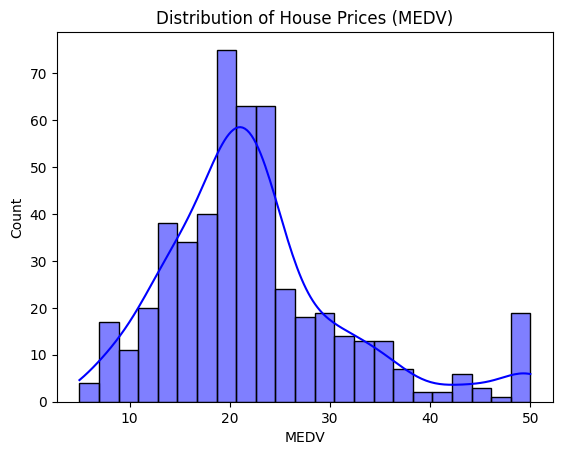

In [59]:
sns.histplot(df['MEDV'], kde=True, color='blue')
plt.title('Distribution of House Prices (MEDV)')
plt.show()


### 1. CRIM (Crime Rate)
*   **Meaning:** Per capita crime rate by town.
*   **Impact:** **Negative.** High crime rates usually lead to lower property values.

### 2. ZN (Zoned Land)
*   **Meaning:** Proportion of residential land zoned for lots over 25,000 sq.ft.
*   **Impact:** **Positive.** This represents large, spacious estates. High `ZN` usually means a wealthy, "suburban" feel.

### 3. INDUS (Industrial)
*   **Meaning:** Proportion of non-retail business acres per town.
*   **Impact:** **Negative.** More factories and industrial zones usually mean more noise and traffic, lowering residential prices.

### 4. CHAS (Charles River)
*   **Meaning:** Charles River dummy variable (1 if tract bounds river; 0 otherwise).
*   **Impact:** **Positive.** Properties with a river view or proximity to the water are almost always more expensive.

### 5. NOX (Nitric Oxides)
*   **Meaning:** Nitric oxides concentration (parts per 10 million).
*   **Impact:** **Negative.** This is a measure of air pollution. High `NOX` levels are found near highways or factories, reducing house value.

### 6. RM (Rooms)
*   **Meaning:** Average number of rooms per dwelling.
*   **Impact:** **Strongly Positive.** This is usually your **most important feature**. More rooms = larger house = higher price.

### 7. AGE (Age)
*   **Meaning:** Proportion of owner-occupied units built prior to 1940.
*   **Impact:** **Negative.** In this specific dataset, "Age" refers to the percentage of *old* houses. Areas with many very old, unrenovated houses often have lower median values.

### 8. DIS (Distance)
*   **Meaning:** Weighted distances to five Boston employment centers.
*   **Impact:** **Mixed.** If it's too far, prices drop (commute is too long). If it's too close, it might be too noisy/crowded. Usually, being reasonably close to jobs increases value.

### 9. RAD (Highway Accessibility)
*   **Meaning:** Index of accessibility to radial highways.
*   **Impact:** **Mixed.** Better access to highways is good for commuters, but being *right next* to a highway is noisy.

### 10. TAX (Property Tax)
*   **Meaning:** Full-value property-tax rate per $10,000.
*   **Impact:** **Negative.** Higher taxes are a financial burden on the owner, which can suppress the market price.

### 11. PTRATIO (Pupil-Teacher Ratio)
*   **Meaning:** Pupil-teacher ratio by town (Schools).
*   **Impact:** **Negative.** A high ratio means crowded schools/fewer teachers. Lower `PTRATIO` (better schools) significantly increases house prices.

### 12. B (Black Population Proxy)
*   **Meaning:** Calculated as $1000(Bk - 0.63)^2$ where $Bk$ is the proportion of people of African American descent by town.
*   **Note:** This is a controversial historical variable used in the 1970s to track socio-economic trends. In modern models, it is often dropped for ethical reasons.

### 13. LSTAT (Lower Status)
*   **Meaning:** Percentage of the population considered "lower status" (based on occupation and education).
*   **Impact:** **Strongly Negative.** This is your **second most important feature**. It represents the socio-economic level of the neighborhood. High `LSTAT` strongly correlates with lower `MEDV`.

### 14. MEDV (Median Value) — **THE TARGET**
*   **Meaning:** Median value of owner-occupied homes in $1000's.
*   **Note:** This is what you are trying to predict. If `MEDV` is 24, the house price is $24,000 (prices are from 1978).

---

### Pro-Tip for your EDA:
When you do your **Correlation Heatmap**, pay the most attention to the relationship between **MEDV** and:
1.  **RM** (Positive correlation: as rooms go up, price goes up).
2.  **LSTAT** (Negative correlation: as poverty goes up, price goes down).
3.  **PTRATIO** (Negative correlation: as school crowding goes up, price goes down).

These three are the "Key Drivers" of this dataset!

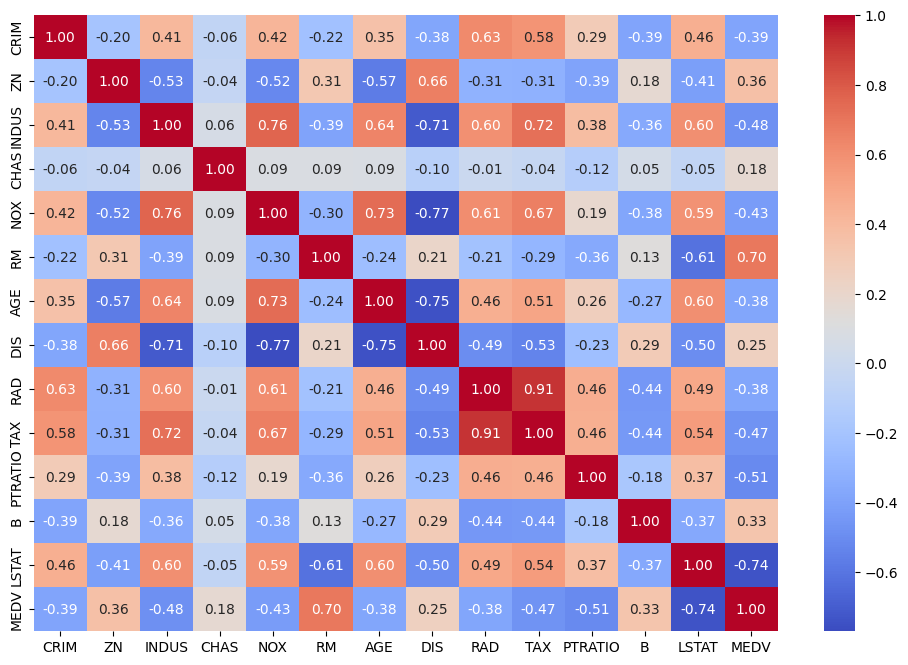

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

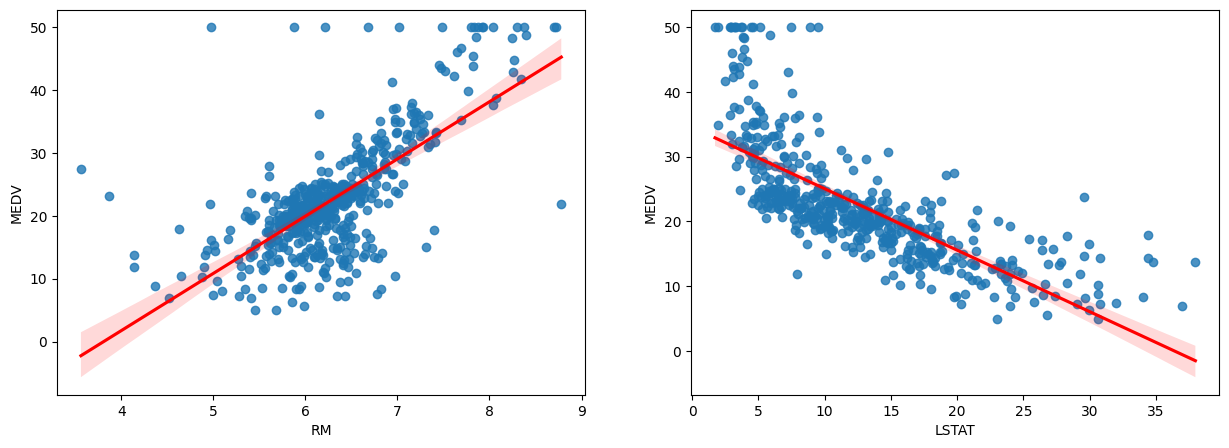

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.regplot(data=df, x='RM', y='MEDV', ax=ax1, line_kws={'color':'red'})
sns.regplot(data=df, x='LSTAT', y='MEDV', ax=ax2, line_kws={'color':'red'})
plt.show()

In [65]:
# Keep only houses priced below the $50k cap
df = df[df['MEDV'] < 50]

In [67]:
df['CRIM'] = np.log1p(df['CRIM'])                                                     

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# 1. Split Features and Target
   
y = df['MEDV']

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling (Ensures features like TAX and RM are on the same scale)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Initialize and Train
# We use max_depth=6 to prevent the model from "memorizing" (overfitting) the data
model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [72]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"R2 Score: {r2:.4f}")
print(f"MAE: ${mae * 1000:,.2f}") # Prices are in $1000s
print(f"RMSE: ${rmse * 1000:,.2f}")

R2 Score: 0.8712
MAE: $1,900.81
RMSE: $2,564.92
